In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [3]:
from src.components.data_ingestion import load_dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = load_dataset()

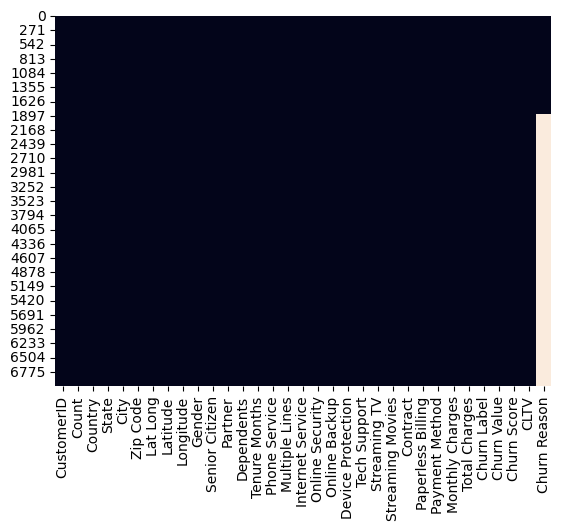

In [7]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [8]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

In [9]:
print(num_cols)
print(cat_cols)

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')
Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Label', 'Churn Reason'],
      dtype='object')


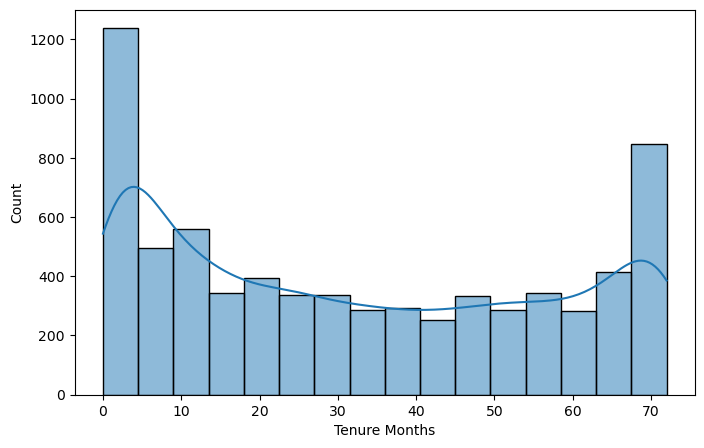

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], kde=True)
plt.show()

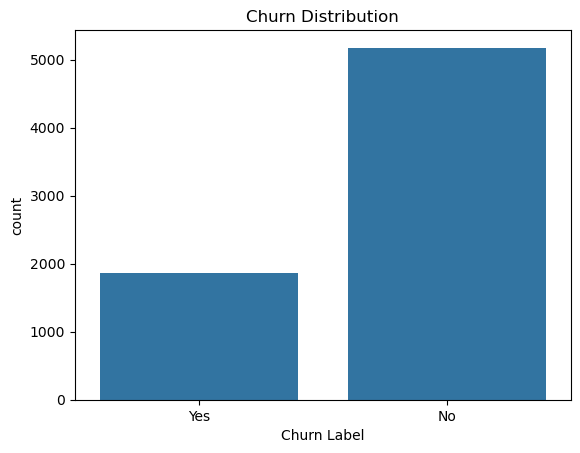

In [12]:
# How many customers churned vs stayed
sns.countplot(x='Churn Label', data=df)
plt.title('Churn Distribution')
plt.show()

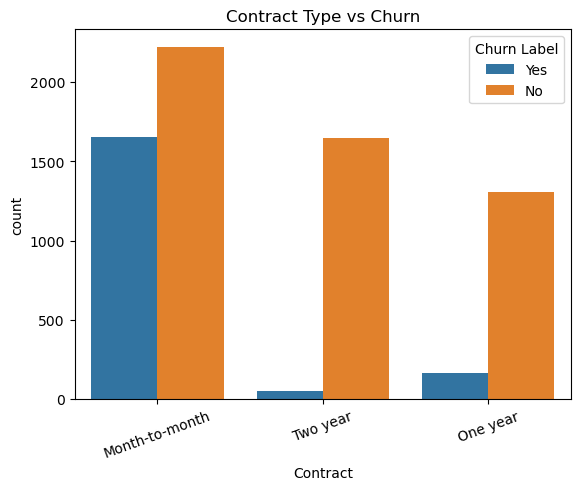

In [15]:
# Which contract type loses the most customers
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.title('Contract Type vs Churn')
plt.xticks(rotation=20)
plt.show()

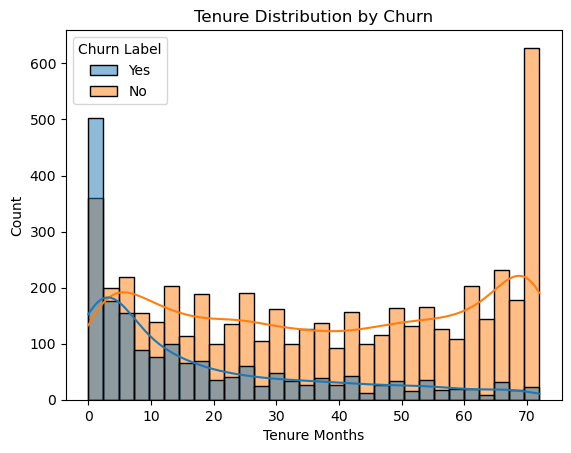

In [19]:
# Are churned customers generally newer customers
sns.histplot(data=df, x='Tenure Months', hue='Churn Label'
             ,bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()

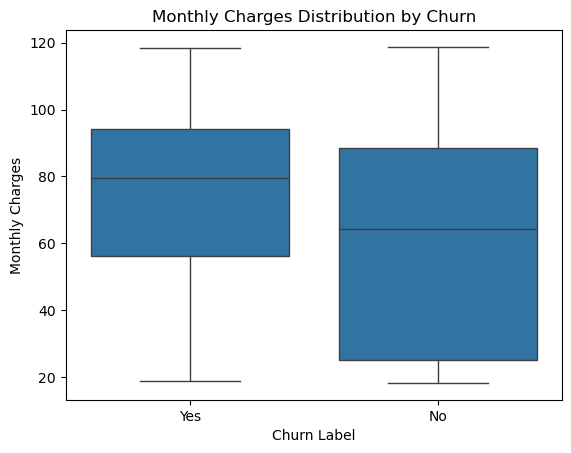

In [21]:
# Do customers paying more churn more
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.title('Monthly Charges Distribution by Churn')
plt.show()

In [27]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors='coerce')

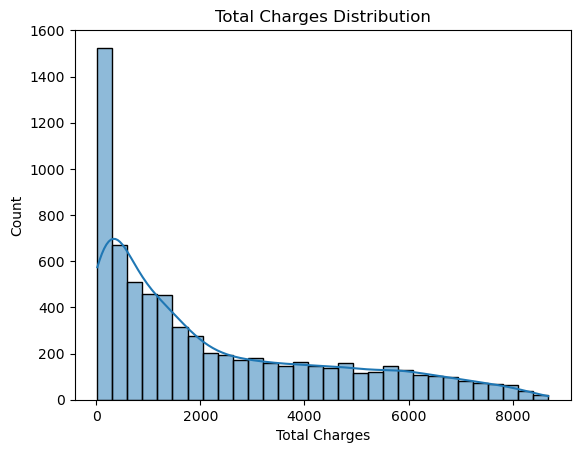

In [28]:
# Total Charges distribution
sns.histplot(df["Total Charges"], bins = 30, kde = True)
plt.title('Total Charges Distribution')
plt.show()

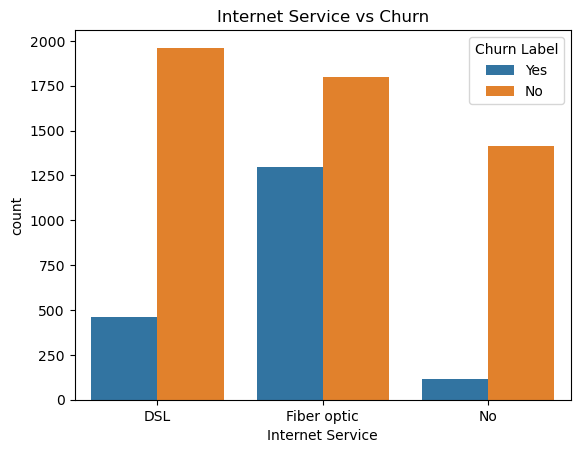

In [29]:
# Which internet service has highest churn
sns.countplot(
    x='Internet Service',
    hue='Churn Label',
    data=df
)
plt.title('Internet Service vs Churn')
plt.show()

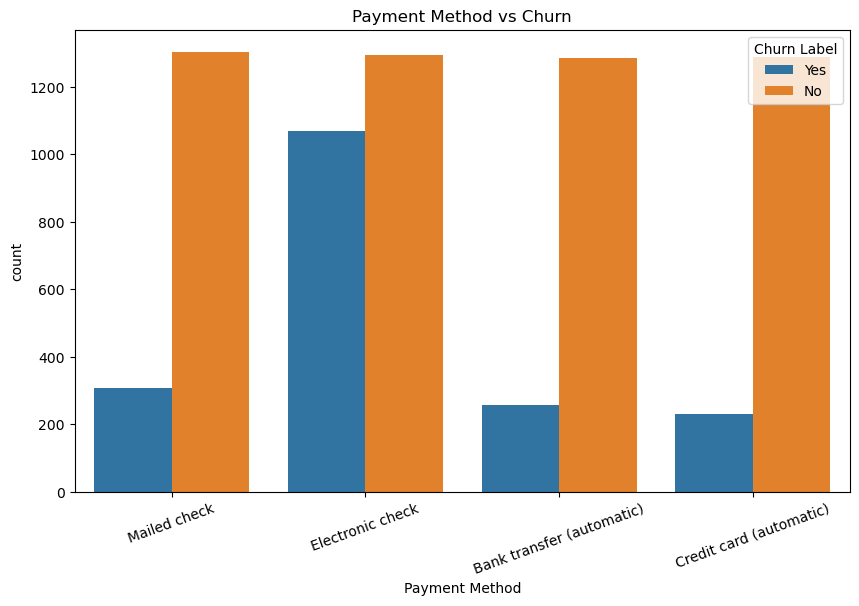

In [31]:
plt.figure(figsize=(10,6))
sns.countplot(
    x='Payment Method',
    hue='Churn Label',
    data=df
)
plt.title('Payment Method vs Churn')
plt.xticks(rotation=20)
plt.show()

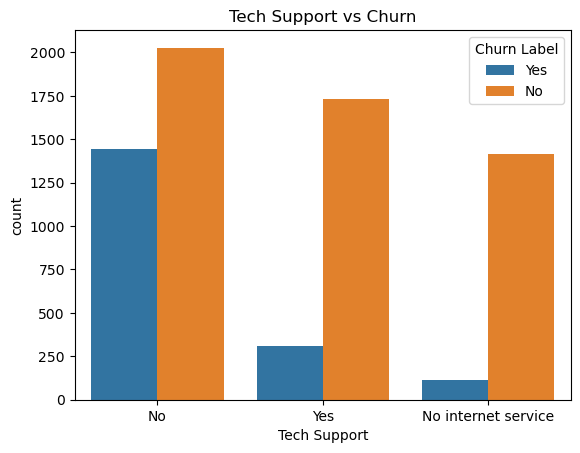

In [32]:
# Tech Support vs Churn
sns.countplot(
    x='Tech Support',
    hue='Churn Label',
    data=df
)
plt.title('Tech Support vs Churn')
plt.show()

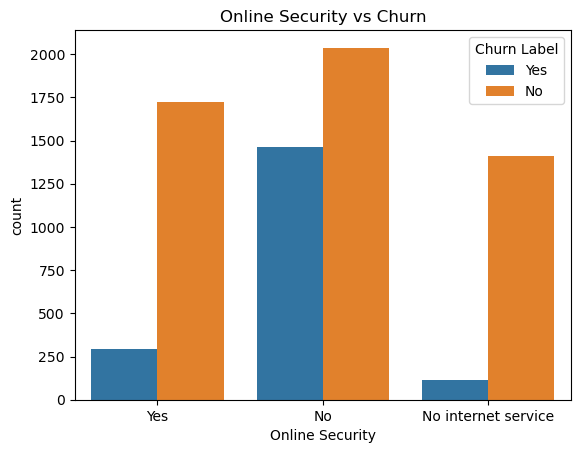

In [33]:
# online security vs churn
sns.countplot(
    x='Online Security',
    hue='Churn Label',
    data=df
)
plt.title('Online Security vs Churn')
plt.show()

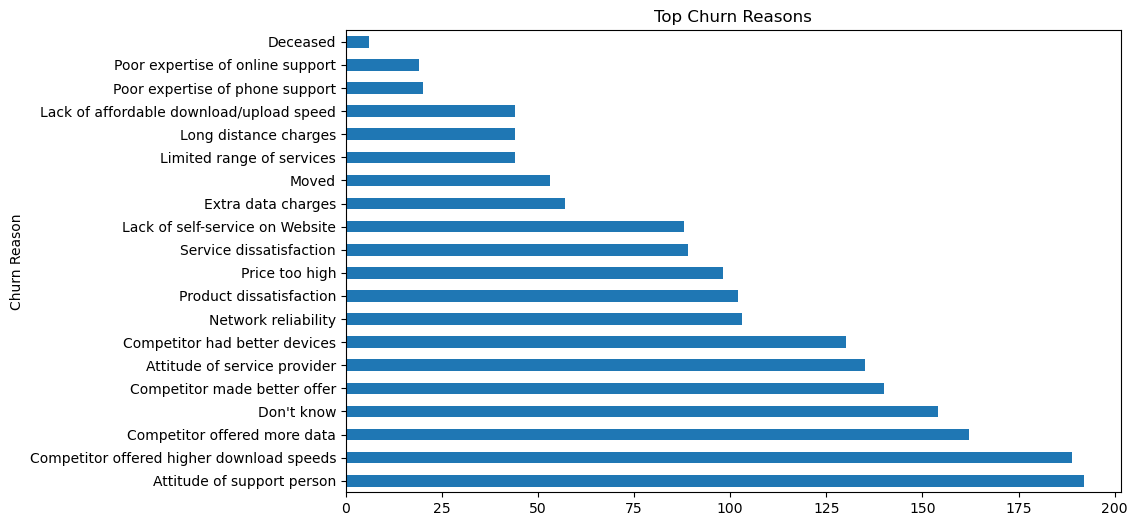

In [35]:
top_reasons = (
    df['Churn Reason']
    .value_counts()
    .head(20)
)

top_reasons.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top Churn Reasons')
plt.show()

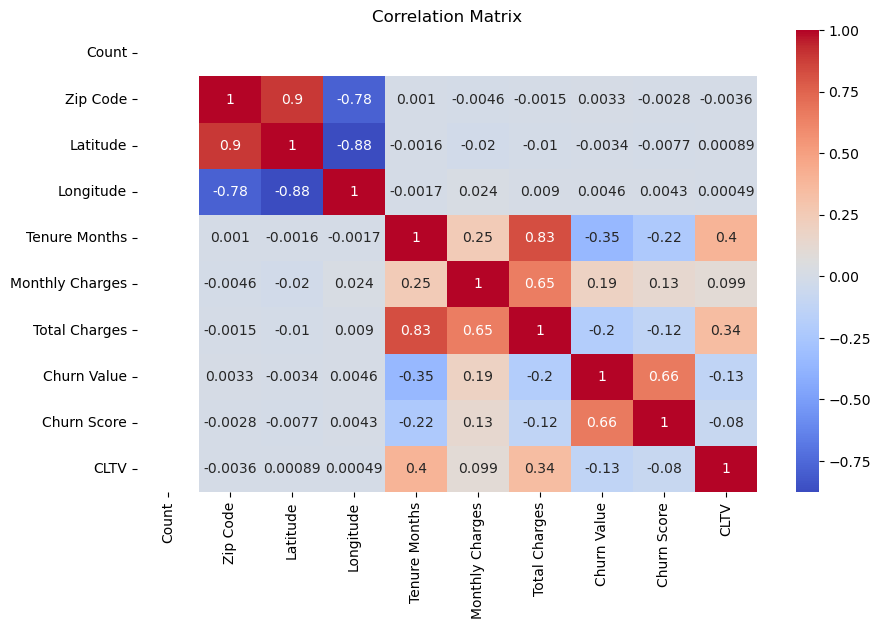

In [36]:
numeric_df = df.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

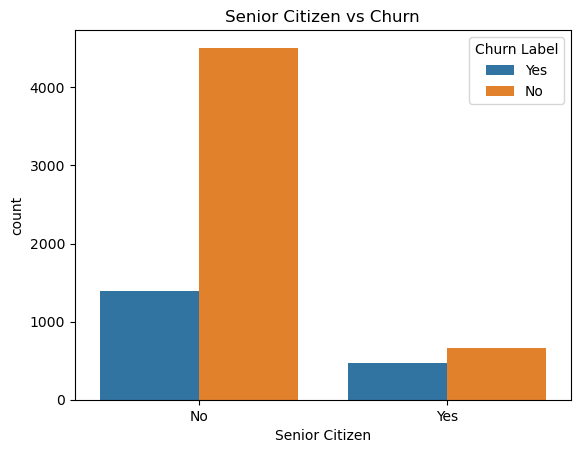

In [37]:
# Are Senior Citizens more likey to churn
sns.countplot(
    x='Senior Citizen',
    hue='Churn Label',
    data=df
)
plt.title('Senior Citizen vs Churn')
plt.show()

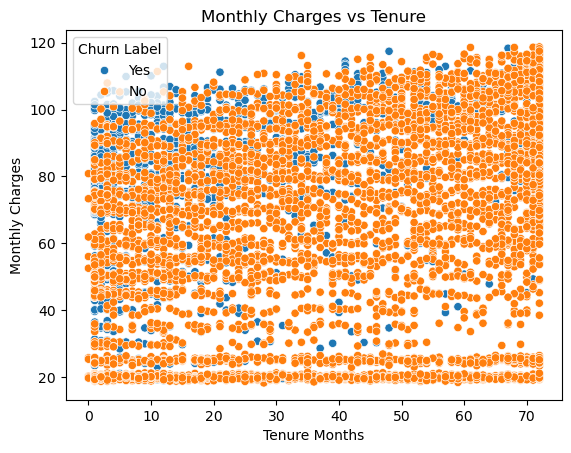

In [38]:
# Monthly Charges vs Tenure
sns.scatterplot(
    x='Tenure Months',
    y='Monthly Charges',
    hue='Churn Label',
    data=df
)
plt.title('Monthly Charges vs Tenure')
plt.show()